In [1]:
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

print("Loading data....")

df = pd.read_excel(url)

print("Data Loaded Successfully")
print(df.head)


Loading data....
Data Loaded Successfully
<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

   

In [2]:
# 1. Drop missing IDs and create a fresh copy (Fixes the Warning)
df = df.dropna(subset=['CustomerID']).copy()

# 2. Convert ID to string (Safe now)
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# 3. Filter out Returns (Negative Quantity) and Bad Prices
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# 4. Create Feature: TotalAmount (Revenue)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(f"Final Cleaned Rows: {df.shape[0]}")
print(df[['InvoiceNo', 'TotalAmount']].head())

Final Cleaned Rows: 397884
  InvoiceNo  TotalAmount
0    536365        15.30
1    536365        20.34
2    536365        22.00
3    536365        20.34
4    536365        20.34


Monthly Revenue Figures:
InvoiceMonth
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: TotalAmount, dtype: float64


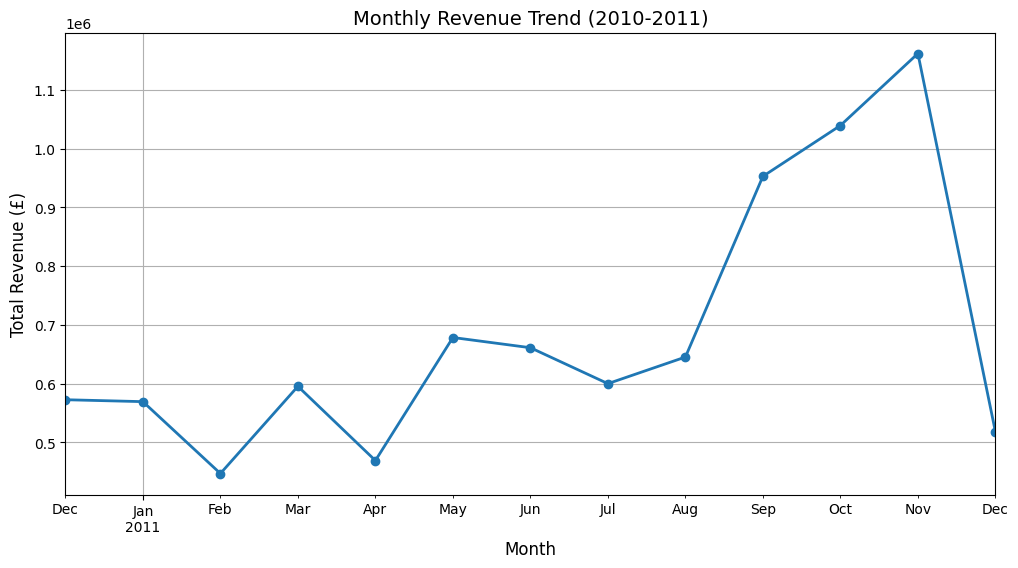

In [3]:
import matplotlib.pyplot as plt

# 1. Ensure InvoiceDate is in datetime format (Crucial for time series)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Create a 'Month' column (Truncates days/times)
# e.g., '2010-12-01 08:26:00' becomes just '2010-12'
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 3. Group by Month and Sum the Revenue
monthly_sales = df.groupby('InvoiceMonth')['TotalAmount'].sum()

# 4. Print the numbers to check values
print("Monthly Revenue Figures:")
print(monthly_sales)

# 5. Visualize it(The Chart)
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='tab:blue', linewidth=2)
plt.title('Monthly Revenue Trend (2010-2011)', fontsize=14)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(True)
plt.show()

In [4]:
# 1. Set a reference date (1 day after the last transaction in the data)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot Date: {snapshot_date}")

# 2. Aggregating data by CustomerID
rfm = df.groupby(['CustomerID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Days difference
    'InvoiceNo': 'nunique',                                  # Frequency: Count unique orders
    'TotalAmount': 'sum'                                     # Monetary: Sum of spend
})

# 3. Rename columns for clarity
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'InvoiceNo': 'Frequency',
                    'TotalAmount': 'Monetary'}, inplace=True)

# 4. Check the first few rows
print("\nRFM Table Created!")
print(rfm.head())

Snapshot Date: 2011-12-10 12:50:00

RFM Table Created!
            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40


In [5]:
# 1. Create labels for scoring (1 to 4)
# For Recency: 4 is best (lowest days), 1 is worst (highest days)
r_labels = range(4, 0, -1)

# For Frequency & Monetary: 1 is worst, 4 is best
f_labels = range(1, 5)
m_labels = range(1, 5)

# 2. Assign scores using qcut
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels)

# Using .rank(method='first') for Frequency because many customers have just 1 order,
# which breaks simple qcut bins.
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

# 3. Concatenate scores to create a "RFM Segment" string (e.g., "444", "111")
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("Scoring Complete!")
print(rfm[['Recency', 'Frequency', 'Monetary', 'RFM_Segment']].head())

Scoring Complete!
            Recency  Frequency  Monetary RFM_Segment
CustomerID                                          
12346           326          1  77183.60         114
12347             2          7   4310.00         444
12348            75          4   1797.24         234
12349            19          1   1757.55         314
12350           310          1    334.40         112


In [6]:
# 1. Define the Business Logic Function
def segment_customer(df):
    if df['RFM_Segment'] == '444':
        return 'Champions' # Bought recently, buy often, spend a lot
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'At Risk' # Big spenders, frequent, but haven't visited lately
    elif df['R_Score'] >= 3 and df['F_Score'] <= 2 and df['M_Score'] <= 2:
        return 'New Customers' # Bought recently, but low frequency/spend
    elif df['RFM_Segment'] == '111':
        return 'Lost Customers' # Haven't bought in ages, low spend, came once
    else:
        return 'Regulars' # Everyone else in the middle

# 2. Apply the function to create a new column
# Convert scores to integers for the logical operators in the function
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['Customer_Type'] = rfm.apply(segment_customer, axis=1)

# 3. See the final breakdown!
print("\nCustomer Segment Distribution:")
print(rfm['Customer_Type'].value_counts())


Customer Segment Distribution:
Customer_Type
Regulars          2570
New Customers      527
Champions          490
At Risk            448
Lost Customers     303
Name: count, dtype: int64


/tmp/ipython-input-3879189999.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Type', y='Count', data=segment_counts, palette='viridis')


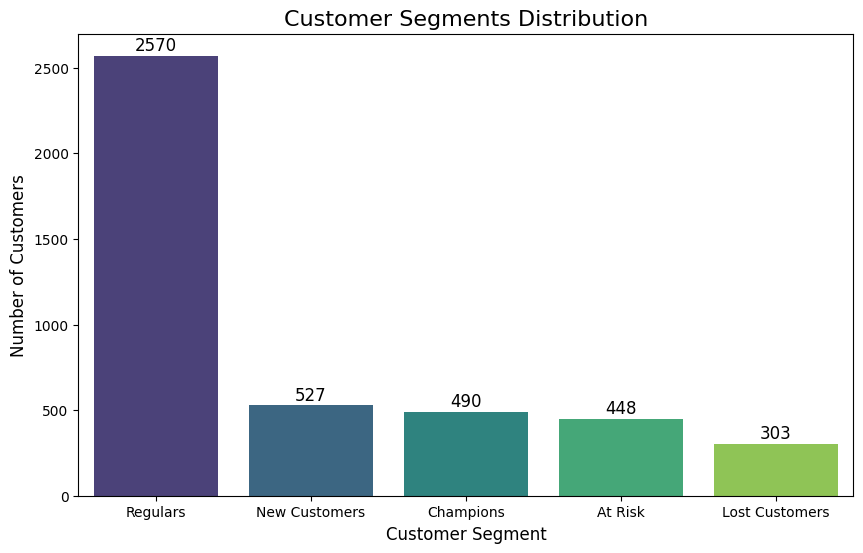

In [7]:
import seaborn as sns

# 1. Count the segments
segment_counts = rfm['Customer_Type'].value_counts().reset_index()
segment_counts.columns = ['Customer_Type', 'Count']

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Customer_Type', y='Count', data=segment_counts, palette='viridis')
plt.title('Customer Segments Distribution', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# 3. Add the numbers on top of the bars for clarity
for index, row in segment_counts.iterrows():
    plt.text(index, row['Count'] + 30, str(row['Count']), ha='center', fontsize=12)

plt.show()

In [8]:
# 1. Create a function to truncate a date to the first day of the month
import datetime as dt

def get_month(x):
    return dt.datetime(x.year, x.month, 1)

# Apply it to InvoiceDate
df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)

# 2. Find the FIRST purchase month for each customer (This is their Cohort)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

print("Cohorts Created!")
print(df[['CustomerID', 'InvoiceMonth', 'CohortMonth']].head())

Cohorts Created!
  CustomerID InvoiceMonth CohortMonth
0      17850   2010-12-01  2010-12-01
1      17850   2010-12-01  2010-12-01
2      17850   2010-12-01  2010-12-01
3      17850   2010-12-01  2010-12-01
4      17850   2010-12-01  2010-12-01


In [9]:
# 1. Extract Year and Month from both columns
def get_date_elements(df, column):
    day = df[column].dt.day
    month = df[column].dt.month
    year = df[column].dt.year
    return year, month, day

invoice_year, invoice_month, _ = get_date_elements(df, 'InvoiceMonth')
cohort_year, cohort_month, _ = get_date_elements(df, 'CohortMonth')

# 2. Calculate the difference in years and months
year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

# 3. Create the Cohort Index (Months passed + 1 so the first month is 1)
df['CohortIndex'] = year_diff * 12 + month_diff + 1

print("Cohort Index Calculated!")
print(df[['CustomerID', 'CohortMonth', 'InvoiceMonth', 'CohortIndex']].head())

Cohort Index Calculated!
  CustomerID CohortMonth InvoiceMonth  CohortIndex
0      17850  2010-12-01   2010-12-01            1
1      17850  2010-12-01   2010-12-01            1
2      17850  2010-12-01   2010-12-01            1
3      17850  2010-12-01   2010-12-01            1
4      17850  2010-12-01   2010-12-01            1


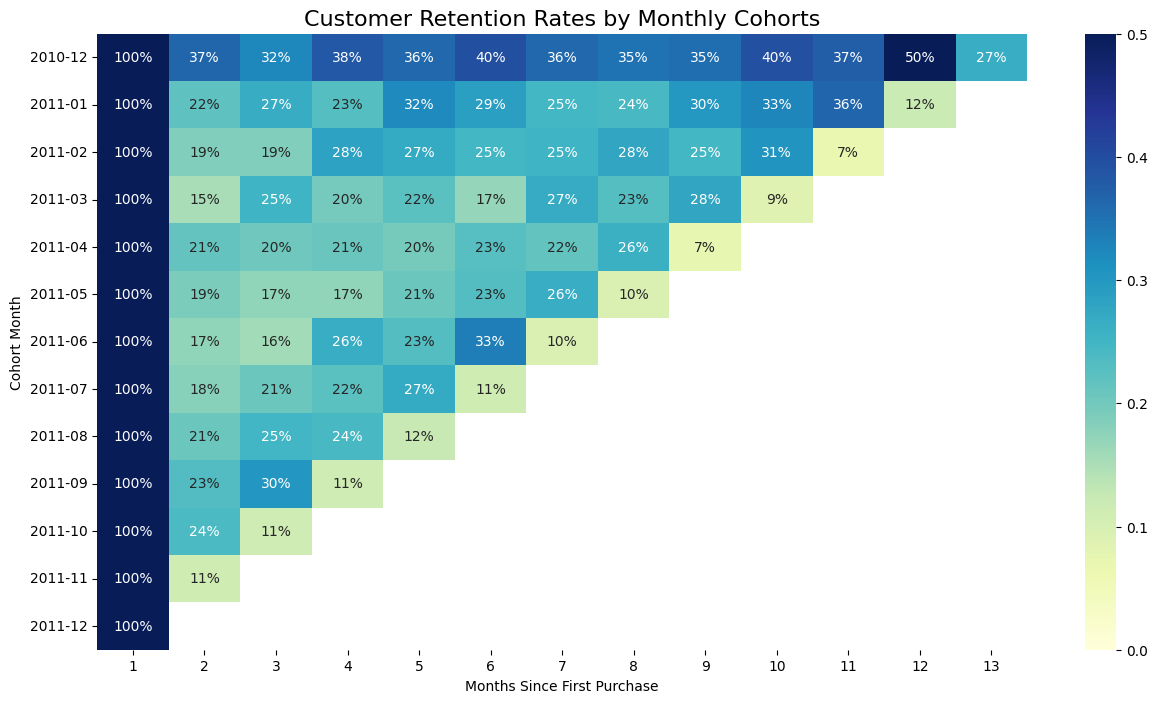

In [10]:
# 1. Group data by Cohort Month and Cohort Index, counting unique Customer IDs
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# 2. Pivot the data into a Matrix (Rows = CohortMonth, Columns = CohortIndex)
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 3. Convert counts to Percentages (Retention Rate)
# Get the first column (Month 1 size) and divide all columns by it
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.strftime('%Y-%m') # Format dates for nice printing

# 4. Plot the Heatmap!
plt.figure(figsize=(15, 8))
plt.title('Customer Retention Rates by Monthly Cohorts', fontsize=16)
sns.heatmap(data=retention,
            annot=True,          # Show numbers
            fmt='.0%',           # Format as percentage
            vmin=0.0, vmax=0.5,  # Scale colors between 0 and 50%
            cmap='YlGnBu')       # Yellow to Blue color map
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

In [11]:
# We need to install the mlxtend library if it's not already in Colab
!pip install mlxtend

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

print("Building the Market Basket for 'France'...")

# 1. Filter for France, group by Invoice and Product, sum the quantities, and unstack into a grid
basket = (df[df['Country'] =="France"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# 2. Convert quantities to 1 (Bought) or 0 (Not Bought)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.applymap(encode_units)

# Remove the 'POSTAGE' column as it's not a real product and skews results
if 'POSTAGE' in basket_sets.columns:
    basket_sets.drop('POSTAGE', inplace=True, axis=1)

print("Basket Built! Running Apriori Algorithm...")

# 3. Find frequent itemsets (Items bought in at least 5% of all French transactions)
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

# 4. Generate the Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 5. Sort by Lift to find the strongest relationships
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

print("\n🔥 Top Product Recommendations (Association Rules):")
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Building the Market Basket for 'France'...


/tmp/ipython-input-399666104.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Basket Built! Running Apriori Algorithm...

🔥 Top Product Recommendations (Association Rules):
                                          antecedents  \
38                     (PACK OF 6 SKULL PAPER PLATES)   
39                       (PACK OF 6 SKULL PAPER CUPS)   
8                     (CHILDRENS CUTLERY DOLLY GIRL )   
9                       (CHILDRENS CUTLERY SPACEBOY )   
69  (ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...   
72                        (ALARM CLOCK BAKELIKE RED )   
73                       (ALARM CLOCK BAKELIKE GREEN)   
68  (ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...   
2                         (ALARM CLOCK BAKELIKE RED )   
3                        (ALARM CLOCK BAKELIKE GREEN)   

                                          consequents   support  confidence  \
38                       (PACK OF 6 SKULL PAPER CUPS)  0.051414    0.909091   
39                     (PACK OF 6 SKULL PAPER PLATES)  0.051414    0.800000   
8                       (CHILDRENS CUTLE

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep